In [1]:
import os
import pickle
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def load_embeddings(user_path, candidate_path):
    with open(user_path, 'rb') as f:
        user_embeddings = pickle.load(f)
    
    with open(candidate_path, 'rb') as f:
        candidate_embeddings_dict = pickle.load(f)
    
    candidate_ids, candidate_embeddings = zip(*candidate_embeddings_dict.items())
    candidate_embeddings = torch.tensor(np.array(candidate_embeddings))
    
    return user_embeddings, candidate_embeddings

def sample_users(user_embeddings, sample_size=10000):
    if len(user_embeddings) > sample_size:
        sampled_indices = np.random.choice(len(user_embeddings), sample_size, replace=False)
        user_embeddings_sample = user_embeddings[sampled_indices]
    else:
        user_embeddings_sample = user_embeddings
    return user_embeddings_sample

def sample_candidates(candidate_embeddings, sample_size=3500):
    if len(candidate_embeddings) > sample_size:
        sampled_indices = np.random.choice(len(candidate_embeddings), sample_size, replace=False)
        candidate_embeddings_sample = candidate_embeddings[sampled_indices]
    else:
        candidate_embeddings_sample = candidate_embeddings
    return candidate_embeddings_sample

def adjust_embedding_dimensions(user_embeddings, candidate_embeddings):
    
    user_interest_dim = user_embeddings.shape[1]  # num_interest for users
    candidate_interest_dim = candidate_embeddings.shape[1]  # num_interest for candidates

    if user_interest_dim != candidate_interest_dim:

        if candidate_interest_dim < user_interest_dim:
            # Repeat candidate embeddings along the interest dimension
            candidate_embeddings = candidate_embeddings.repeat(1, user_interest_dim, 1)
        else:
            # Truncate candidate embeddings to match user embeddings' interest dimension
            candidate_embeddings = candidate_embeddings[:, :user_interest_dim, :]
    
    return candidate_embeddings


def calculate_scores(user_embeddings, candidate_embeddings, scoring_fn, batch_size=64):
    user_embeddings = torch.tensor(user_embeddings)
    candidate_embeddings = candidate_embeddings

    num_users = user_embeddings.size(0)
    num_candidates = candidate_embeddings.size(0)
    
    scores = torch.empty((num_users, num_candidates))

    for i in range(0, num_users, batch_size):
        user_batch = user_embeddings[i:i+batch_size]
        user_batch_expanded = user_batch.unsqueeze(1).expand(-1, num_candidates, -1, -1)
        candidate_embeddings_expanded = candidate_embeddings.squeeze(1).expand(user_batch.size(0), num_candidates, -1, -1)

        batch_scores = scoring_fn(user_batch_expanded, candidate_embeddings_expanded, dim=-1).mean(dim=-1)
        scores[i:i+batch_size] = batch_scores

    return scores

def analyze_scores(scores):
    mean_scores_per_user = scores.mean(axis=1)
    mean_scores_per_candidate = scores.mean(axis=0)
    std_scores_per_candidate = scores.std(axis=0)
    var_scores_per_candidate = scores.var(axis=0)

    return mean_scores_per_user, mean_scores_per_candidate, std_scores_per_candidate, var_scores_per_candidate

def plot_scores(mean_scores, std_scores, var_scores):
    sorted_indices = np.argsort(mean_scores)
    sorted_mean_scores = mean_scores[sorted_indices]
    sorted_std_scores = std_scores[sorted_indices]
    sorted_var_scores = var_scores[sorted_indices]

    plt.figure(figsize=(10, 6))
    plt.plot(sorted_mean_scores, label='Mean Recommendation Score')
    plt.fill_between(range(len(sorted_mean_scores)), sorted_mean_scores - sorted_std_scores, sorted_mean_scores + sorted_std_scores, alpha=0.2, label='Standard Deviation', color='blue')
    plt.fill_between(range(len(sorted_mean_scores)), sorted_mean_scores - sorted_var_scores, sorted_mean_scores + sorted_var_scores, alpha=0.1, label='Variance', color='yellow')
    plt.xlabel('News sorted by their mean recommendation score')
    plt.ylabel('Recommendation score')
    plt.legend()
    plt.show()

def process_embeddings(N, user_path, candidate_path, scoring_fn=torch.nn.functional.cosine_similarity):
    print(f'Processing for N={N}')
    user_embeddings, candidate_embeddings = load_embeddings(user_path, candidate_path)
    candidate_embeddings = adjust_embedding_dimensions(user_embeddings, candidate_embeddings)
    user_embeddings_sample = sample_users(user_embeddings)
    candidate_embeddings_sample = sample_candidates(candidate_embeddings)   
    scores = calculate_scores(user_embeddings_sample, candidate_embeddings_sample, scoring_fn)
    mean_scores_per_user, mean_scores_per_candidate, std_scores_per_candidate, var_scores_per_candidate = analyze_scores(scores)
    plot_scores(mean_scores_per_candidate, std_scores_per_candidate, var_scores_per_candidate)

# Define the candidate path
candidate_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/dev_candidate_embeddings.pkl'


Processing for N=5


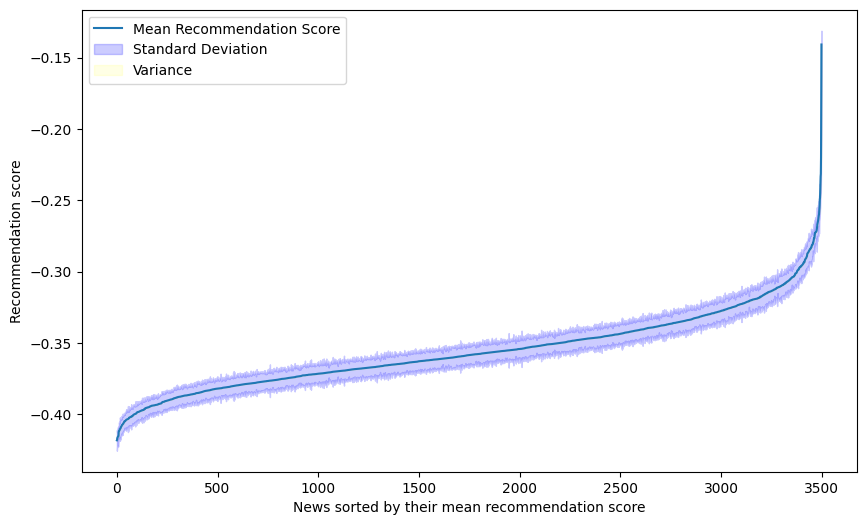

In [2]:
#Without Disentanglement Loss

# Configuration for N = 5
process_embeddings(
    N=5,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing for N=10


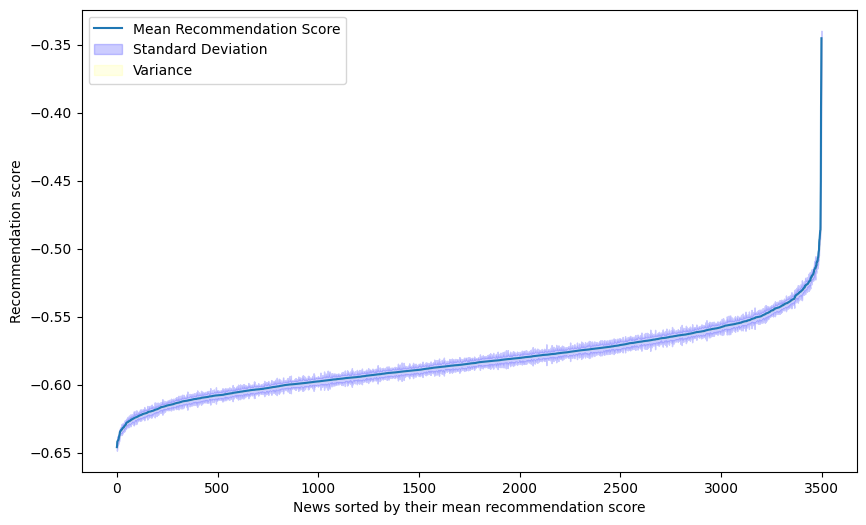

In [3]:
#N=10 
process_embeddings(
    N=10,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing for N=25


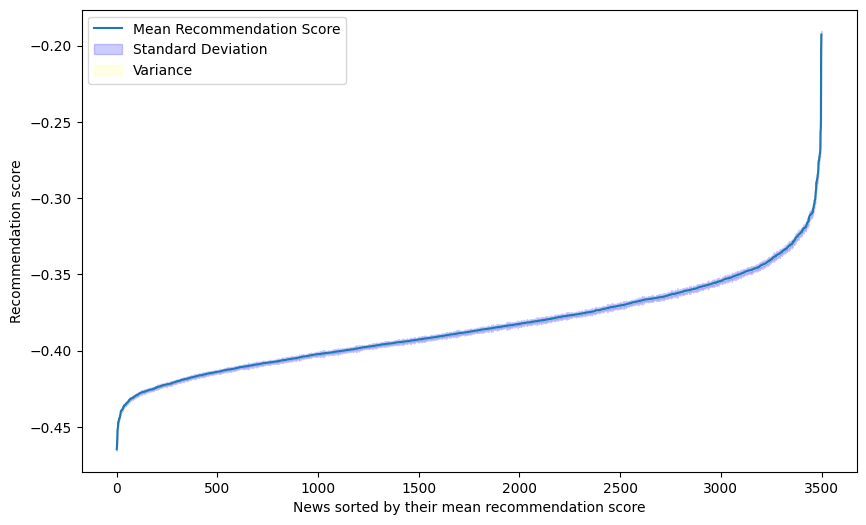

In [4]:
#N=25
process_embeddings(
    N=25,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing for N=50


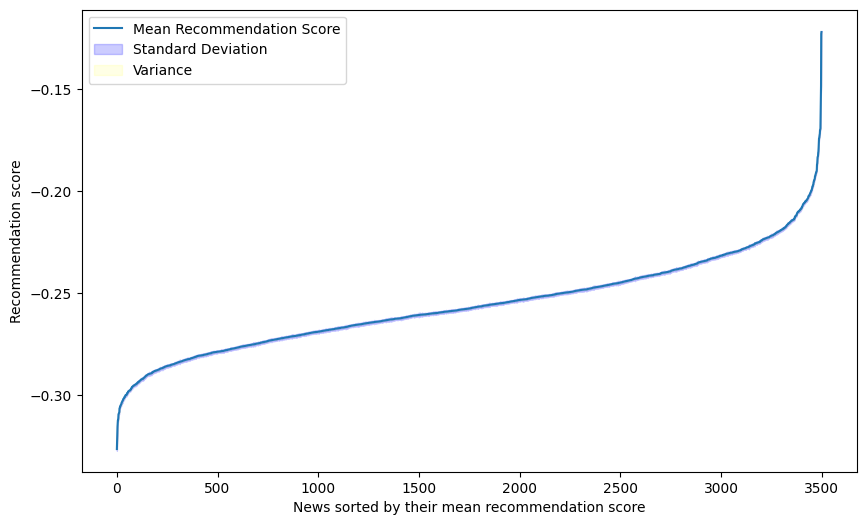

In [5]:
#N=50
process_embeddings(
    N=50,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing for N=5


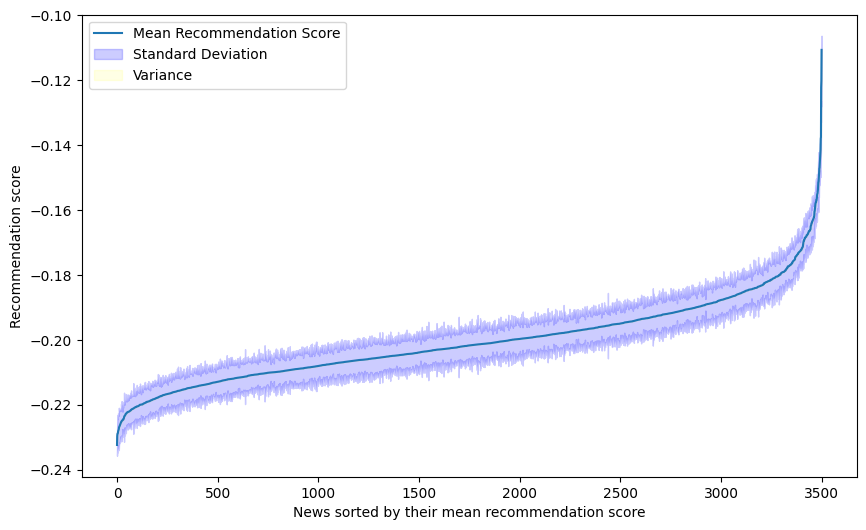

In [6]:
# With Disentanglement Loss for N = 5, 10, 25, 50 with lambda_s = 0.9 

# Configuration for N = 5
process_embeddings(
    N=5,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    candidate_path=candidate_path
)

Processing for N=10


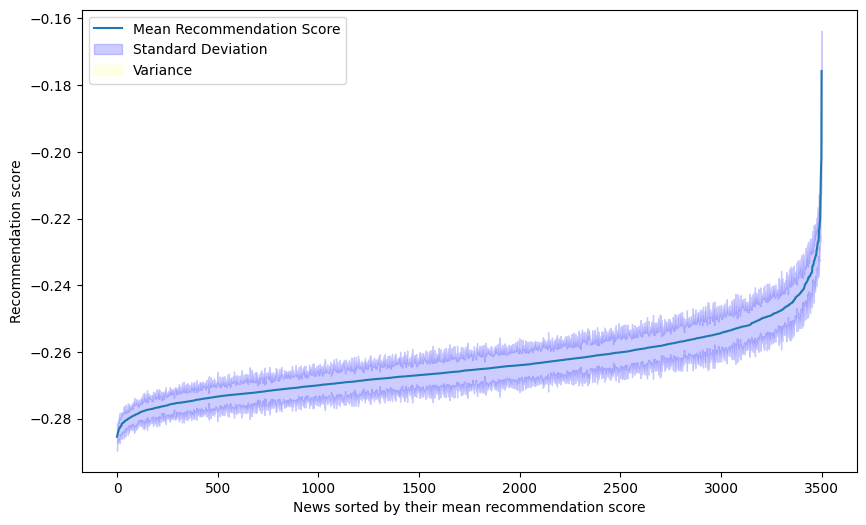

In [7]:
#N=10, lambda_s = 0.9
process_embeddings(
    N=10,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl',
    candidate_path=candidate_path
)

Processing for N=25


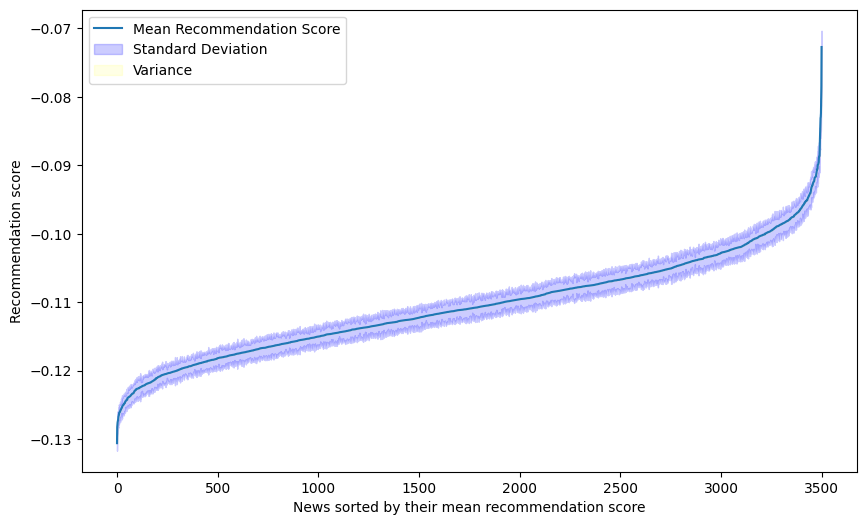

In [8]:
#N=25, lambda_s = 0.9 
process_embeddings(
    N=25,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    candidate_path=candidate_path
)

Processing for N=50


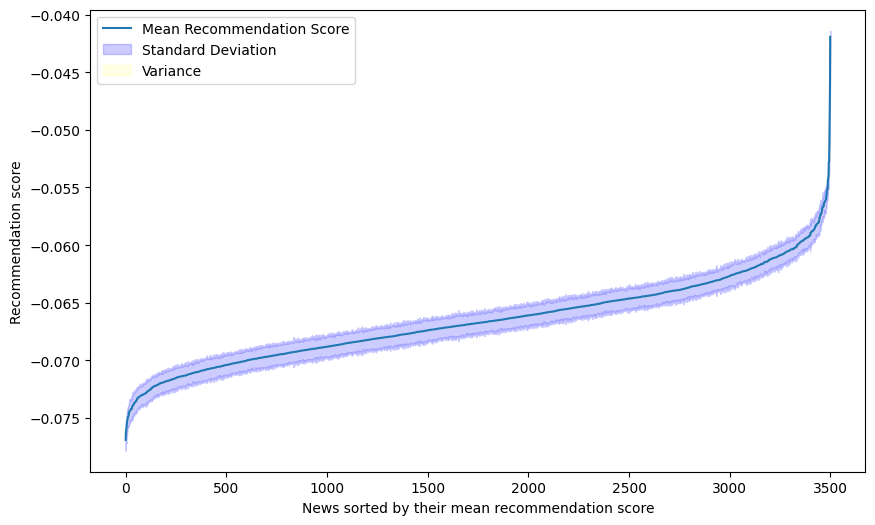

In [9]:
#N=50, lambda_s = 0.9
process_embeddings(
    N=50,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl',
    candidate_path=candidate_path
)